In this notebook I'm looking at a simple CNN trained on a variant of the MNIST dataset. The task is digit classification, and my goal is to understand not just whether the model gets things right, but what parts of the image it actually looks at when making a decision.

I chose two XAI techniques for this: Integrated Gradients and Grad-CAM. I picked these beacuse they approach the problem from completely different angles. IG works at the pixel level while Grad-CAM works at the feature map level. If both methods point to the same region I can be more confident that it actually matters to the model.

In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients, LayerGradCam
import warnings
warnings.filterwarnings("ignore")

c:\Users\aaron\miniconda3\envs\ml-bachelor-eai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define the CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
# Load the models best weights
model = SimpleCNN()
model.load_state_dict(torch.load('../models/challenge_model.pth'))
model.eval()

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [3]:
# Load data and labels
challenge_images = np.load('../data/challenge_images.npy')
challenge_labels = np.load('../data/challenge_labels.npy')
print(f"Loaded challenge images: {challenge_images.shape}, labels: {challenge_labels.shape}")

Loaded challenge images: (10, 1, 28, 28), labels: (10,)


In [4]:
def to_input(img):
    img = np.asarray(img, dtype=np.float32)
    if img.ndim == 2:
        img = img[np.newaxis]  # (H, W) → (1, H, W)
    # img is now (1, H, W); add batch dim → (1, 1, H, W)
    return torch.from_numpy(img).unsqueeze(0)

def show_attr(images, labels, attr_maps, title, cmap='hot', alpha=0.5):
    fig, axs = plt.subplots(2, 5, figsize=(16, 7))
    for i, ax in enumerate(axs.ravel()):
        m = attr_maps[i]
        m = (m - m.min()) / (m.max() - m.min() + 1e-9)
        ax.imshow(images[i].squeeze(), cmap='gray')
        ax.imshow(m, cmap=cmap, alpha=alpha)
        ax.set_title(f"label {int(labels[i])}", fontsize=9)
        ax.axis('off')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

### 1. Model Predictions

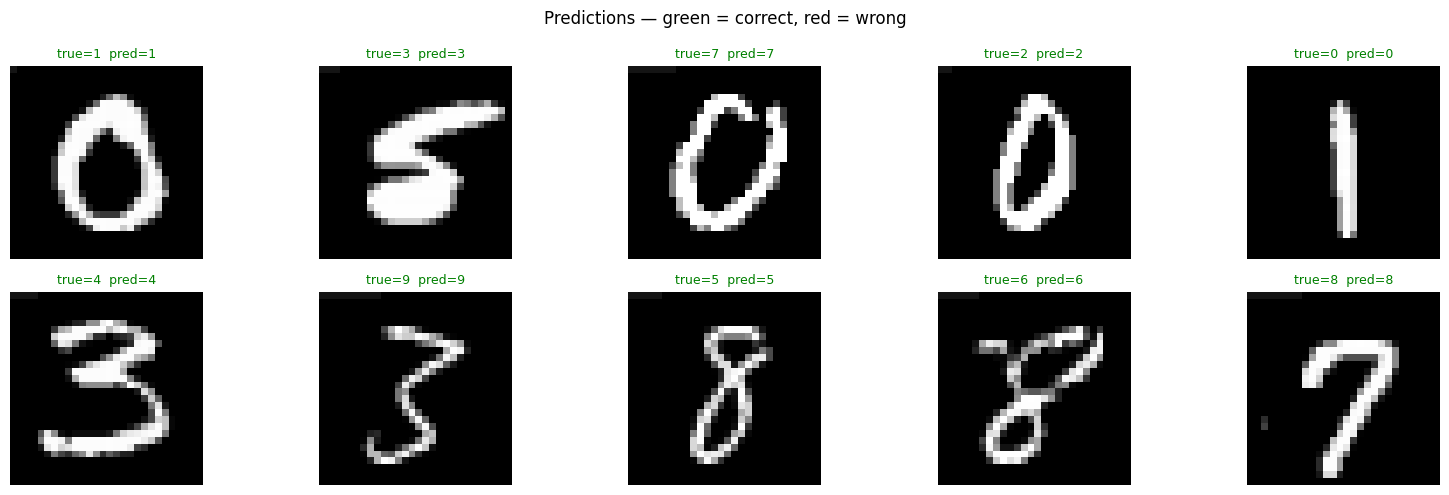

In [5]:
# Quick check: see what the model predicts vs. the true label for all 10 images
fig, axs = plt.subplots(2, 5, figsize=(16, 5))
for i, ax in enumerate(axs.ravel()):
    with torch.no_grad():
        pred = model(to_input(challenge_images[i])).argmax(1).item()
    true = int(challenge_labels[i])
    ax.imshow(challenge_images[i].squeeze(), cmap='gray')
    ax.set_title(f"true={true}  pred={pred}", fontsize=9,
                 color='green' if pred == true else 'red')
    ax.axis('off')
plt.suptitle("Predictions — green = correct, red = wrong")
plt.tight_layout()
plt.show()

### 2. Integrated Gradients

To understand why Integrated Gradients is useful it helps to first look at why simpler gradient approaches don't work that well.

The most obvious thing you could try is vanilla gradients, meaning you compute the gradient of the output class score with respect to each input pixel. This tells you how sensitive the prediction is to a small change at each pixel right now. Two problems: the gradient is measured at a single point so it tends to be noisy, and if a ReLU activation has saturated the gradient is zero even for pixels that clearly mattered earlier in the computation. You'd miss them entirely.

Gradient x Input is a small improvement. You multiply each gradient by the pixel value to get a rough estimate of contribution rather than just sensitivity. But it has a hidden zero baseline and doesn't actually fix the saturation issue. Integrated Gradients is the proper solution to both.

IG takes the gradient not at one point but along a straight-line path from a baseline to the actual input, and averages them over roughly 50 steps. The formula is:

$$\text{IG}_i(x) = (x_i - x'_i) \times \int_0^1 \frac{\partial F(x' + \alpha(x - x'))}{\partial x_i} \, d\alpha$$

where $x'$ is the baseline and $\alpha$ goes from 0 to 1. Averaging over the full path avoids the saturation problem. The gradient is non-zero at earlier steps even if the final activation is saturated.

The property I find most useful here is completeness: the attributions sum to exactly $F(x) - F(x')$. Every bit of the difference between predicting on the actual image and the baseline is accounted for, nothing disappears and nothing gets double-counted.

**Baseline choice:** I used a black image (all zeros). For MNIST-style data this is the natural choice since the background is already black, so it works as a no signal starting point. A different baseline like random noise or a white image would shift the attributions since IG is always measuring relative to whatever you set as the starting point. That's worth keeping in mind when reading the maps.

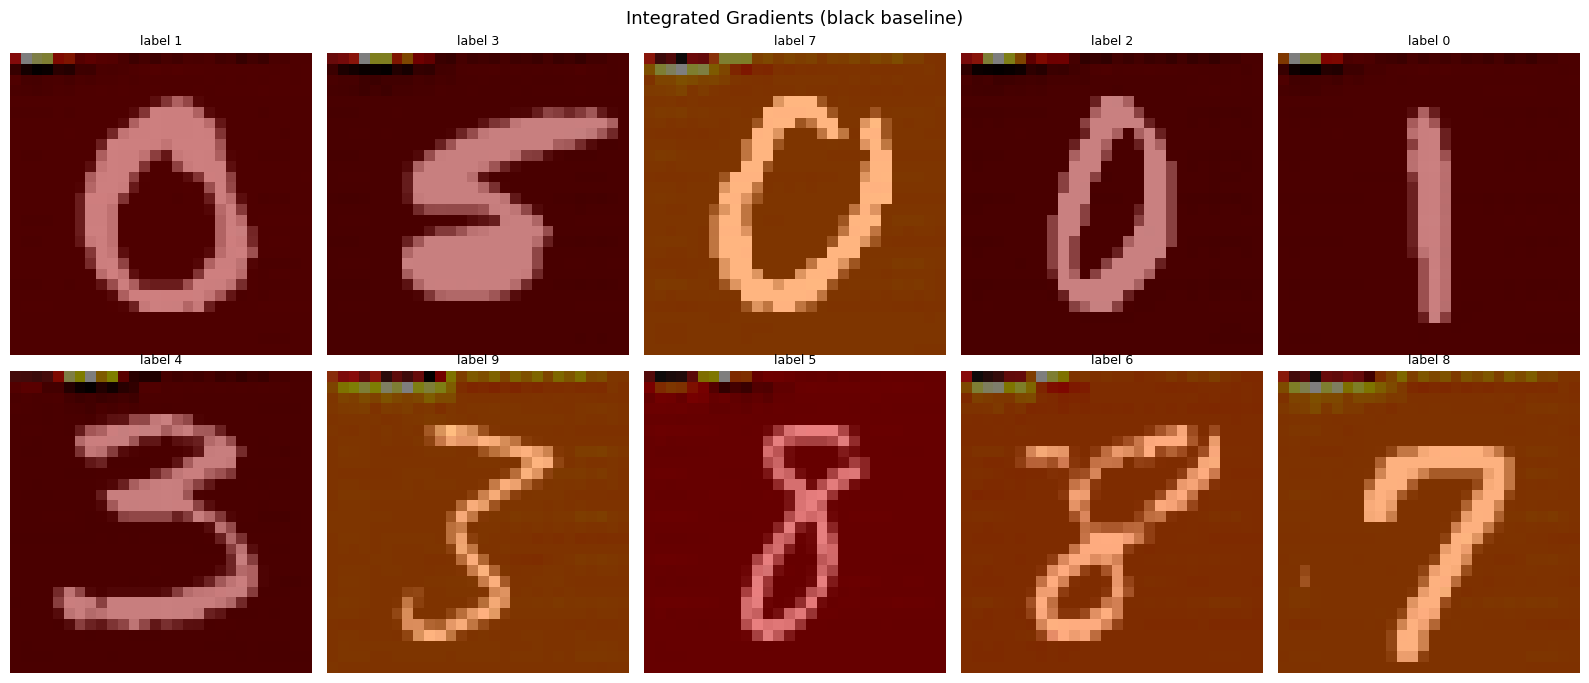

In [6]:
ig = IntegratedGradients(model)

ig_maps = []
for i in range(len(challenge_images)):
    inp = to_input(challenge_images[i])
    attr = ig.attribute(inp, target=int(challenge_labels[i]))
    ig_maps.append(attr.squeeze().detach().numpy())

show_attr(challenge_images, challenge_labels, ig_maps, "Integrated Gradients (black baseline)")

The plot above overlays the attributions on the original image, which helps with spatial context but hides the sign of the attributions. Negative values get shifted up by the min-max normalization and end up looking similar to weak positive ones. The plot below shows the raw maps on their own with a diverging colormap, the same way notebook 6 does it. Red means that pixel pushed the prediction up, blue means it pushed it down.

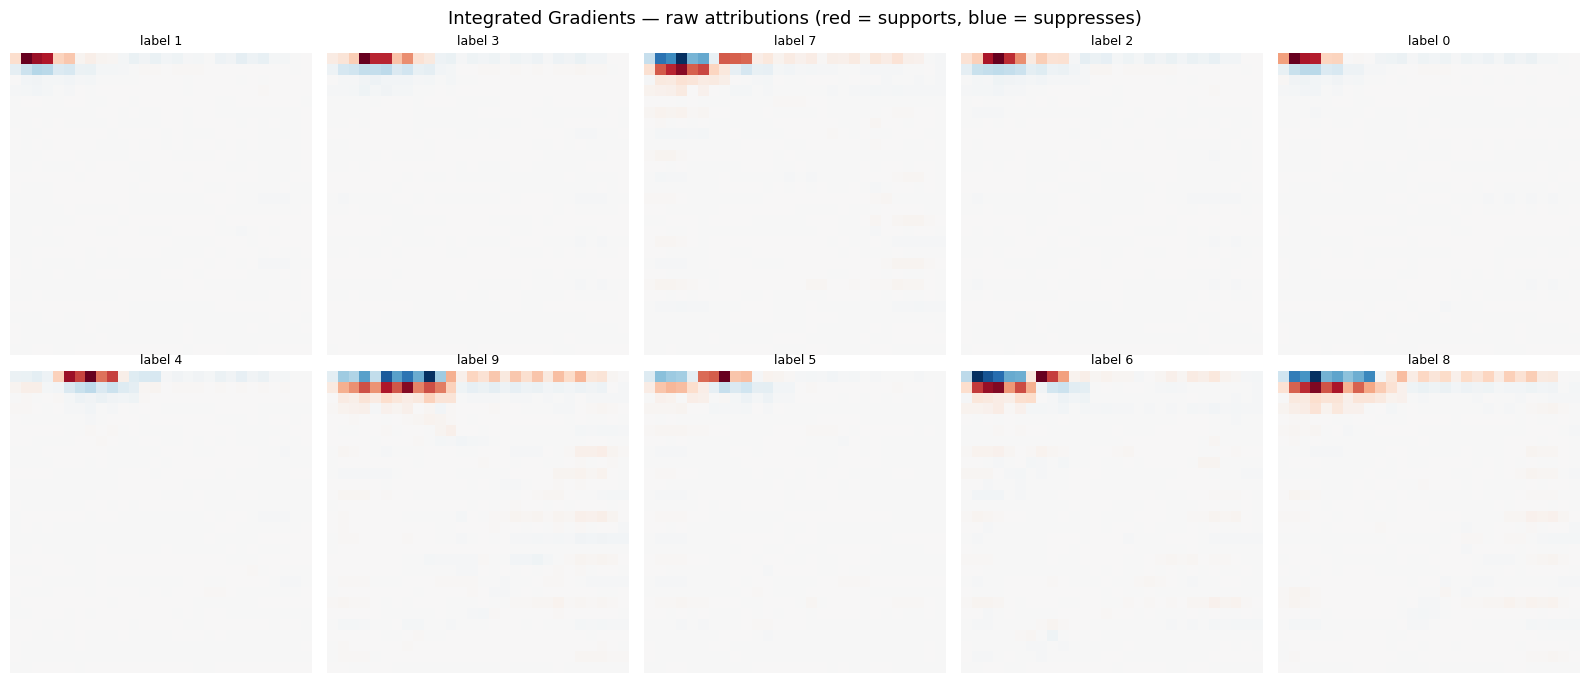

In [7]:
# Standalone IG attribution maps — raw signed values, no overlay
fig, axs = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axs.ravel()):
    m = ig_maps[i]
    vmax = np.abs(m).max() + 1e-9
    ax.imshow(m, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f"label {int(challenge_labels[i])}", fontsize=9)
    ax.axis('off')
plt.suptitle("Integrated Gradients — raw attributions (red = supports, blue = suppresses)", fontsize=13)
plt.tight_layout()
plt.show()

The raw diverging plot is harder to read and reveals an interesting issue. Almost all the colored signal ends up in a narrow strip at the very top of each image, while the digit areas appear near-white. A few pixels at the image boundary have much larger absolute attribution values than the pixels on the actual digit strokes. The symmetric colormap scales to the maximum absolute value, so the digit-level attributions become invisible next to those edge values. This is probably a border artifact from the padding in the convolutional layers creating stronger gradient responses at the image edges.

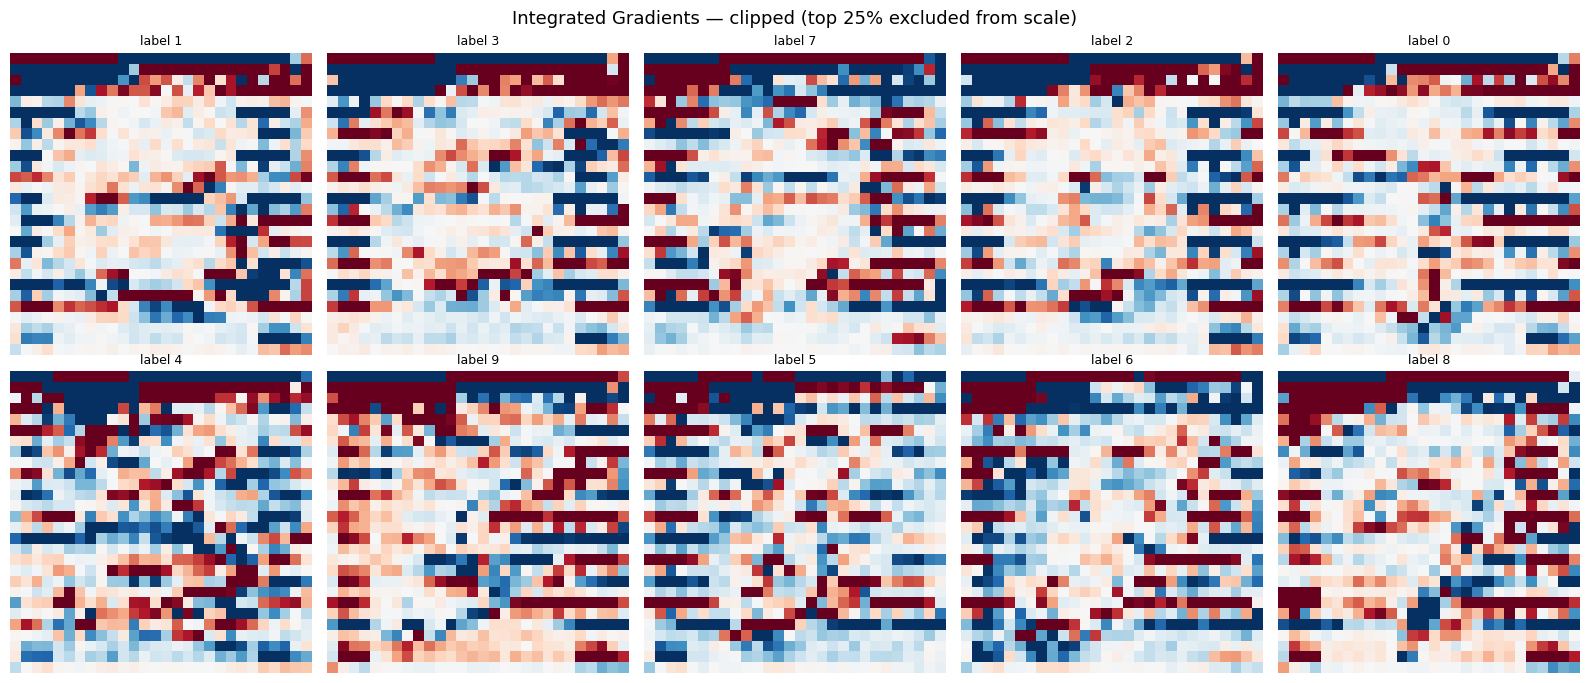

In [69]:
# IG attribution maps — percentile clipped (top 25% excluded from scale)
fig, axs = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axs.ravel()):
    m = ig_maps[i]
    vmax = np.percentile(np.abs(m), 75) + 1e-9
    ax.imshow(m, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f"label {int(challenge_labels[i])}", fontsize=9)
    ax.axis('off')
plt.suptitle("Integrated Gradients — clipped (top 25% excluded from scale)", fontsize=13)
plt.tight_layout()
plt.show()

The clipped version fixes this by setting vmax to the 75th percentile of absolute attribution values, so the top 25% of values get saturated instead of stretching the whole scale. With that the digit strokes become clearly visible as red regions across all ten images. The pattern lines up with the overlay plot, the model is attending to the actual pen strokes and not the background. The edge artifact is still there but it no longer drowns out everything else.

I'm not fully sure the edge values are purely a visualization artifact though. The model might genuinely assign high attribution to border pixels because of the conv padding or because some digits have strokes near the edge. The clipped plot makes it clear the digit region matters, but what's driving those extreme edge values would be worth looking into.

#### Experiment: Normalized dark background

One thing I wanted to check is whether the grayscale background values are affecting the IG maps. The background looks black visually but MNIST pixels are floating point and some background pixels are not exactly zero. Since IG measures contribution relative to the black baseline, any pixel that is not exactly zero will pick up a small attribution it probably should not have.

Instead of setting dark pixels to exact zero I set them to a small uniform value (0.05), so the background is consistently slightly lighter dark rather than a mix of near-zero noise. Bright stroke pixels keep their original values. The model does not need retraining for this, I just apply the normalization before passing the images in.

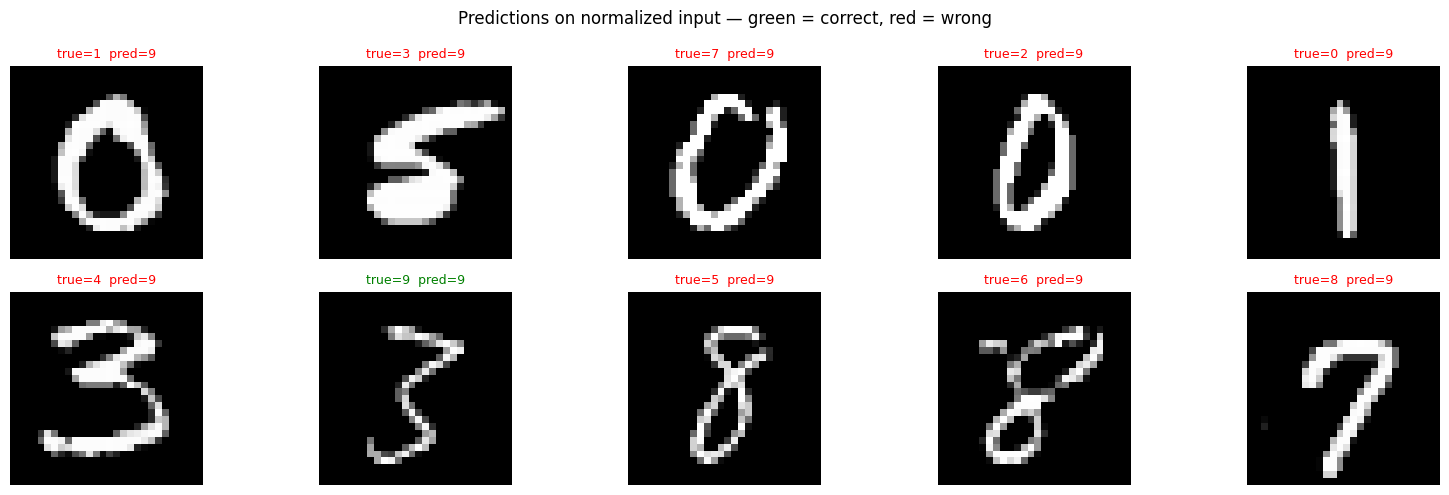

In [76]:
# Normalize challenge images — dark pixels (below threshold) are set to a slightly lighter dark value
threshold = 0.1
dark_fill = 0.05
binarized_images = np.where(challenge_images > threshold, challenge_images, dark_fill).astype(np.float32)

# Verify predictions still hold on normalized input
fig, axs = plt.subplots(2, 5, figsize=(16, 5))
for i, ax in enumerate(axs.ravel()):
    with torch.no_grad():
        pred = model(to_input(binarized_images[i])).argmax(1).item()
    true = int(challenge_labels[i])
    ax.imshow(binarized_images[i].squeeze(), cmap='gray')
    ax.set_title(f"true={true}  pred={pred}", fontsize=9,
                 color='green' if pred == true else 'red')
    ax.axis('off')
plt.suptitle("Predictions on normalized input — green = correct, red = wrong")
plt.tight_layout()
plt.show()

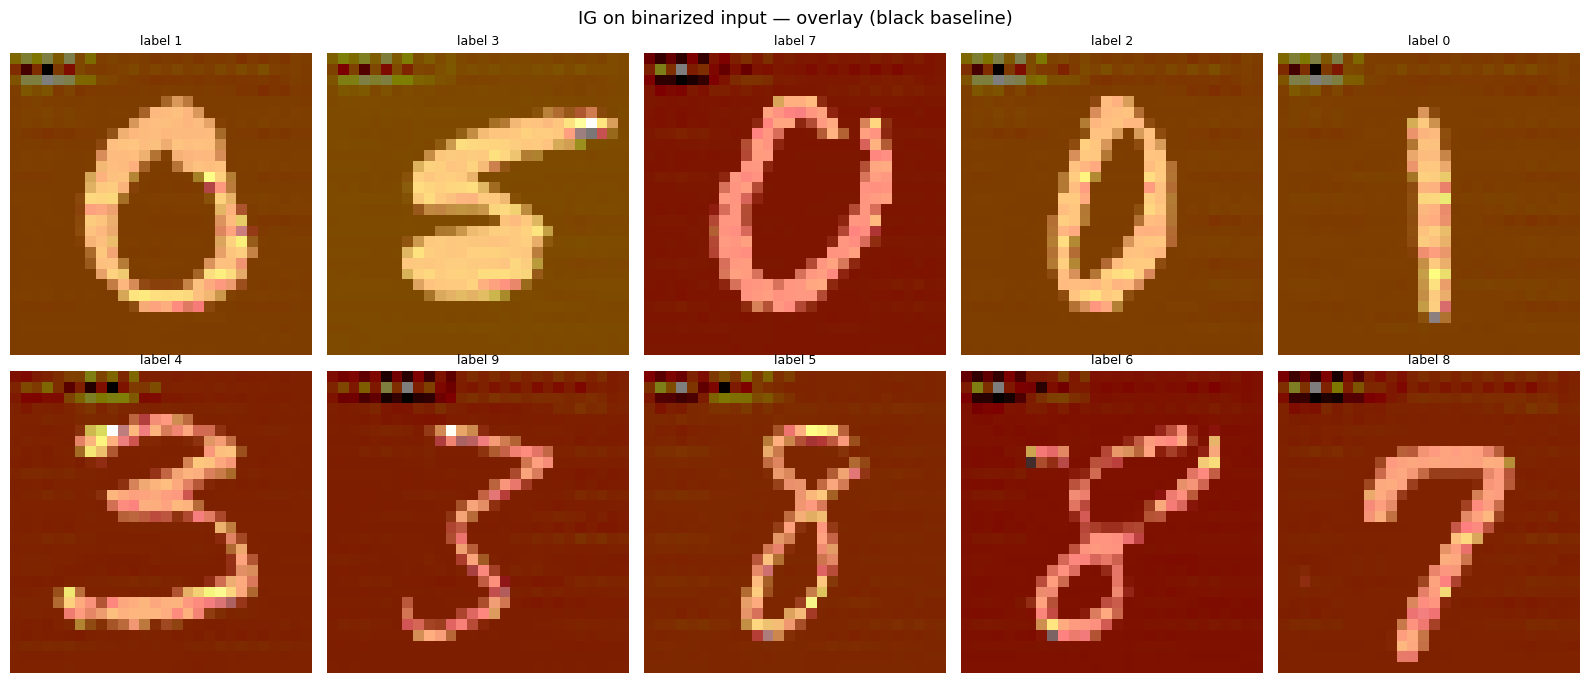

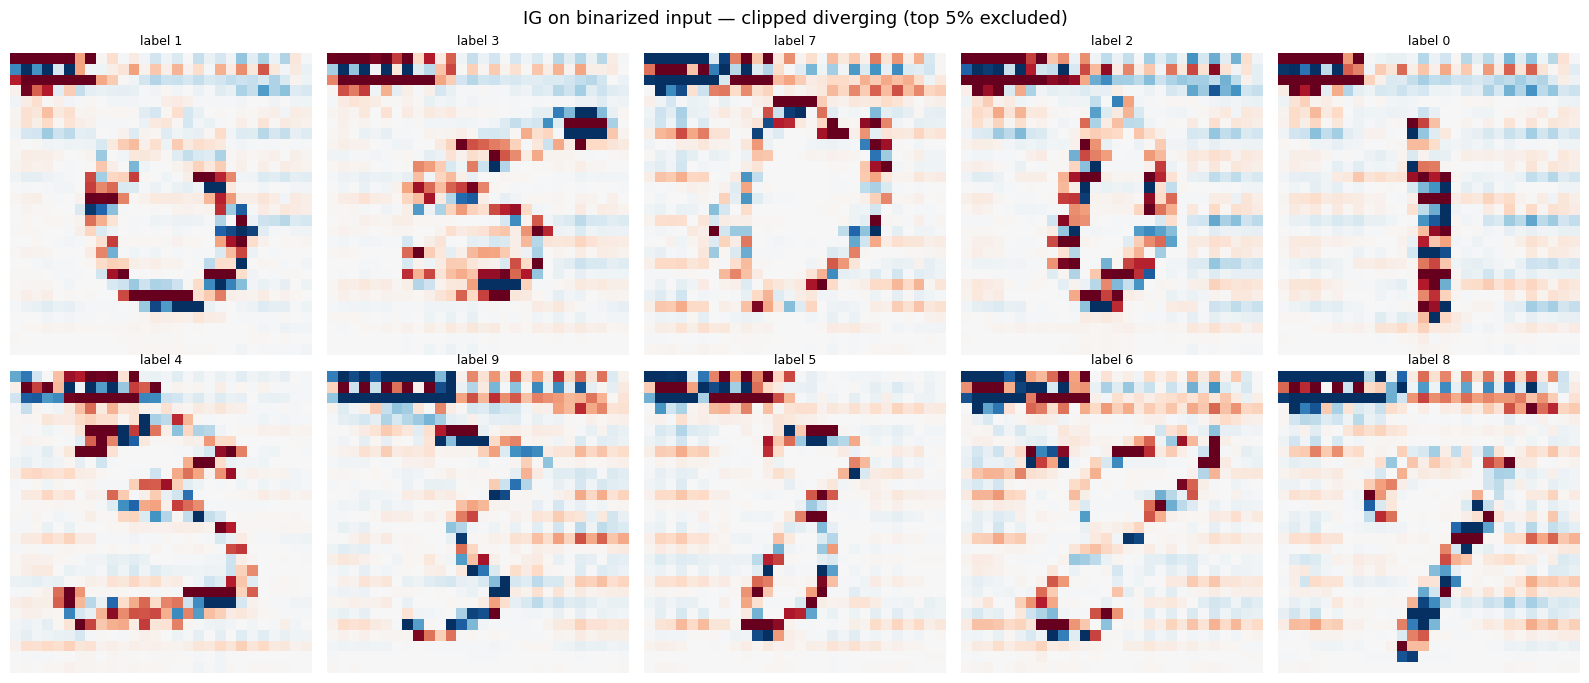

In [77]:
# Run IG on binarized images
ig_maps_bin = []
for i in range(len(binarized_images)):
    inp = to_input(binarized_images[i])
    attr = ig.attribute(inp, target=int(challenge_labels[i]))
    ig_maps_bin.append(attr.squeeze().detach().numpy())

show_attr(binarized_images, challenge_labels, ig_maps_bin,
          "IG on binarized input — overlay (black baseline)")

# Clipped diverging plot
fig, axs = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axs.ravel()):
    m = ig_maps_bin[i]
    vmax = np.percentile(np.abs(m), 95) + 1e-9
    ax.imshow(m, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f"label {int(challenge_labels[i])}", fontsize=9)
    ax.axis('off')
plt.suptitle("IG on binarized input — clipped diverging (top 5% excluded)", fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation - Normalized background experiment:**

The first thing to notice is that the model breaks completely. Every single image gets predicted as class 9 regardless of the true label, with only the one actual 9 classified correctly. I didn't expect this. Shifting the dark background pixels from near-zero to 0.05 is a tiny change visually, but it's enough to push the model off its predictions across the whole dataset.

This is actually a more interesting result than what I was originally looking for. The model was trained on images where the background is essentially zero. The IG black baseline is also zero. So both the input and the baseline share that same background level, which is part of why IG works cleanly on these images. As soon as the background is uniformly lifted to 0.05, the model collapses to predicting 9 for everything. That's a sign the model is relying on more than just the stroke shape. It's sensitive to the absolute pixel values in the background region in a way that isn't obvious from the normal predictions.

Because the model is predicting class 9 for every image, the IG maps in the overlay and diverging plots are no longer showing what matters for the true class. They're showing what features push the prediction toward 9. The overlay still traces roughly digit-shaped regions which is a bit confusing, but that's because the path from the 0 baseline to the normalized input still passes through the stroke pixels. The diverging clipped plot shows scattered red and blue attributions along the digit areas, more visible than in the original clipped plot, but less meaningful since the model is wrong. The top-edge artifact is still present in both plots.

The original goal was a cleaner IG baseline by normalizing the background. Instead this experiment showed the model isn't robust to even small background shifts, which is worth noting in itself.

### 3. Grad-CAM

Grad-CAM (Gradient-weighted Class Activation Mapping) is an extension of the original CAM method. Original CAM only worked on networks with a specific architecture, convolutional layers straight into global average pooling into a linear classifier. Grad-CAM removes that constraint by using gradients to figure out which feature maps mattered, rather than reading the weights from the classifier directly. This means it works on any convolutional layer in any CNN.

The idea is to look at a chosen convolutional layer and ask: for this target class, how much did each feature map at that layer contribute? Feature maps with large positive gradients were helpful for the prediction; ones with near-zero gradients basically didn't do anything. You weight the feature maps by those gradients, sum them up, and apply ReLU to keep only the positive contributions.

The weight for each feature map $k$ is the global average of the gradient of the target class score $y^c$ with respect to that map's activations $A^k$:

$$\alpha_k^c = \frac{1}{Z} \sum_i \sum_j \frac{\partial y^c}{\partial A_{ij}^k}$$

The heatmap is then:

$$L^c = \text{ReLU}\!\left(\sum_k \alpha_k^c \cdot A^k\right)$$

I ran this on `conv2`, the last conv layer before pooling. Earlier layers mostly respond to low-level features like edges, so `conv2` gives the best trade-off between spatial resolution and meaningful, class-relevant features.

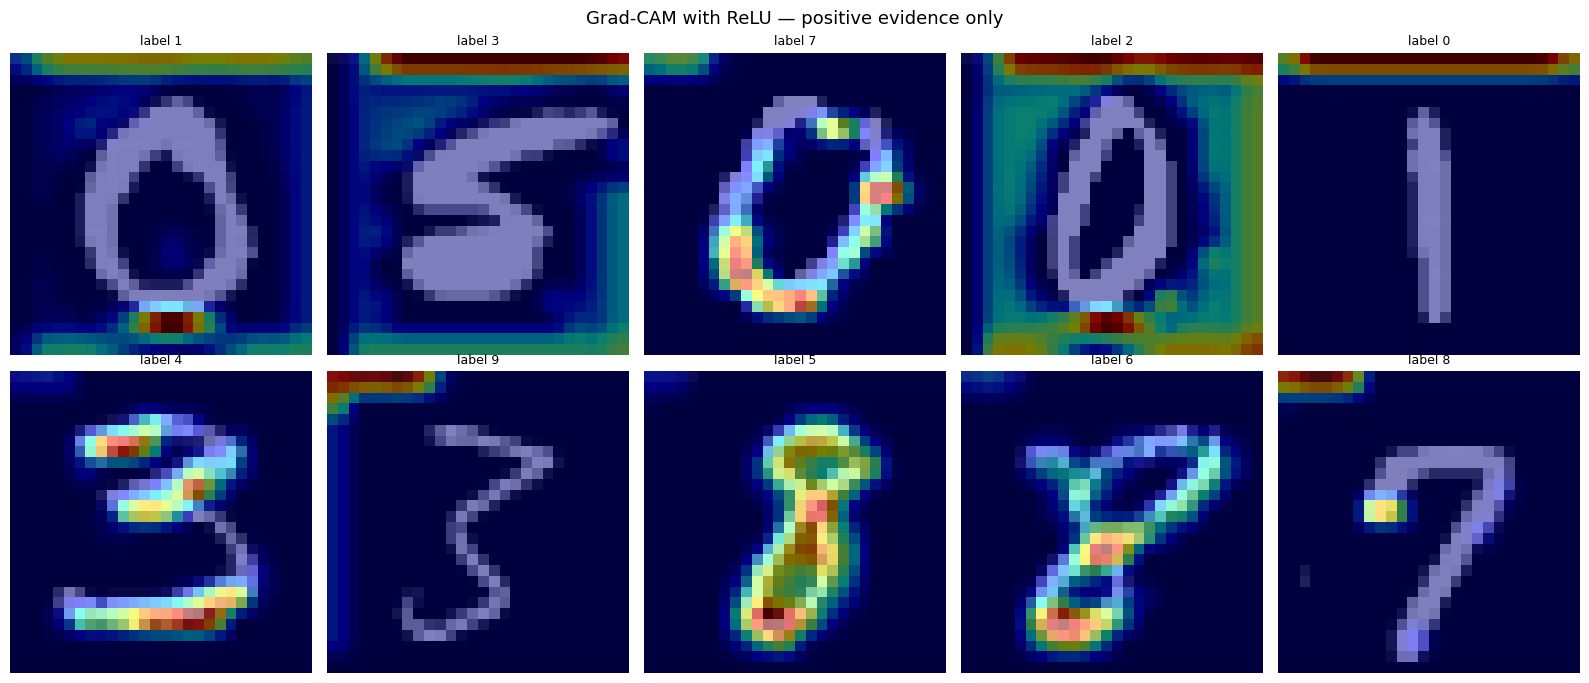

In [8]:
grad_cam = LayerGradCam(model, model.conv2)

gcam_maps = []
for i in range(len(challenge_images)):
    inp = to_input(challenge_images[i])
    attr = grad_cam.attribute(inp, target=int(challenge_labels[i]), relu_attributions=True)
    attr = F.interpolate(attr, size=(28, 28), mode='bilinear', align_corners=False)
    gcam_maps.append(attr.squeeze().detach().numpy())

show_attr(challenge_images, challenge_labels, gcam_maps, "Grad-CAM with ReLU — positive evidence only", cmap='jet')

**Interpretation - Grad-CAM with ReLU:**

The heatmap follows the digit strokes for most images and the overall picture makes sense. The network is clearly responding to the actual digit shape rather than empty space. Complex digits like label 5 (the 8-shape) and label 4 (the 3-shape) show strong red/yellow activation along their characteristic curves and junctions.

There's one obvious artifact though. Some images have a bright activation strip at the bottom or top of the frame, and some also have hot spots in the corners. That's not part of the digit and is a bit suspicious. It's probably a systematic response of the conv2 layer to the image boundary, since padding or border effects during convolution can create artificially strong feature map responses at the edges. Label 9 (the wavy 3-shape) also has noticeably weaker activation than the others, which might just mean this particular example is written in a less distinctive way.

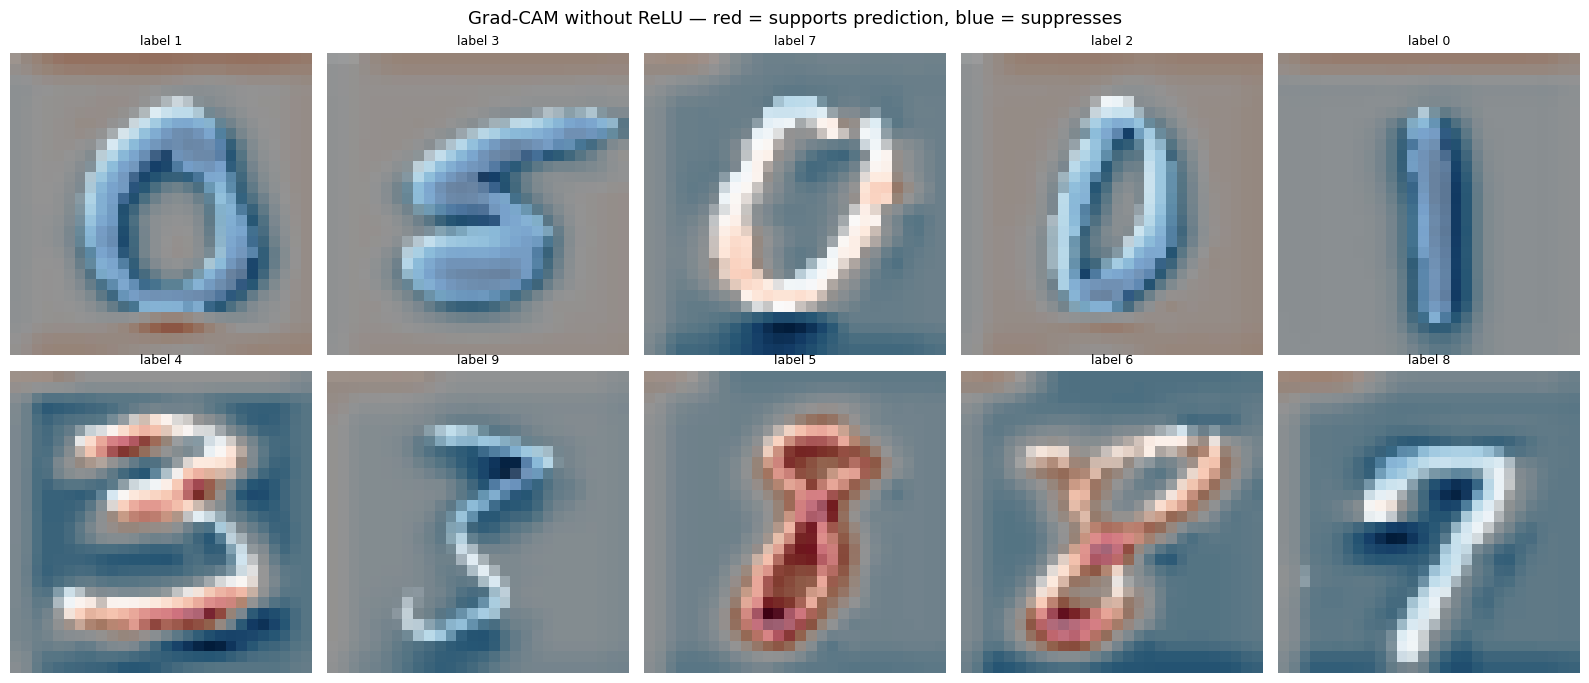

In [9]:
# Grad-CAM without ReLU — raw signed attributions
raw_gcam_maps = []
for i in range(len(challenge_images)):
    inp = to_input(challenge_images[i])
    attr = grad_cam.attribute(inp, target=int(challenge_labels[i]), relu_attributions=False)
    attr = F.interpolate(attr, size=(28, 28), mode='bilinear', align_corners=False)
    raw_gcam_maps.append(attr.squeeze().detach().numpy())

fig, axs = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axs.ravel()):
    m = raw_gcam_maps[i]
    vmax = np.abs(m).max() + 1e-9
    ax.imshow(challenge_images[i].squeeze(), cmap='gray')
    ax.imshow(m, cmap='RdBu_r', alpha=0.6, vmin=-vmax, vmax=vmax)
    ax.set_title(f"label {int(challenge_labels[i])}", fontsize=9)
    ax.axis('off')
plt.suptitle("Grad-CAM without ReLU — red = supports prediction, blue = suppresses", fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation - Grad-CAM without ReLU:**

Looking at this without the ReLU, most of the digit stroke area shows up blue, meaning those parts are actually suppressing the predicted class in the conv2 feature maps rather than supporting it. The ReLU version was hiding this completely. The red spots are much more selective and concentrate on specific structural features like junctions and curves that are more distinctive for each class.

This actually makes sense for classification. The model doesn't just need to detect a stroke, it needs to distinguish between classes that share a lot of visual structure. Labels 5 and 6 both show 8-like shapes for example. The red regions end up highlighting the parts that are most class-specific rather than the whole stroke. The background stays near-zero which is reassuring since there's no strong activation on empty space.

The bottom-edge artifact from the with-ReLU plot mostly disappears here, which suggests those edge activations were positive but small. Without the ReLU zeroing out the negatives the overall color balance shifts and the edge effect gets drowned out.

### 4. Analysis

**Why these two techniques**

I went with IG and Grad-CAM because they look at the model from different levels of abstraction. IG gives pixel-level attributions with a completeness guarantee. Grad-CAM gives a coarser, feature-map-level view of which spatial region the convolutional layer responded to. If both methods agree on a region I find that more convincing than relying on just one, since they work in completely different ways and make different assumptions.

**What the maps show**

Both methods consistently put the attention on the digit strokes and ignore the background. The IG overlay is precise enough that you can basically trace the pen strokes from the heatmap. The raw diverging IG plot is dominated by border artifacts that hide the digit signal, which is why I added a clipped version scaled to the 75th percentile. With the clipping the digit strokes show up clearly as red attributions across all ten images, consistent with what the overlay already showed. The Grad-CAM maps are coarser because of the 7x7 to 28x28 upsampling, but they land on the same general region. Removing the ReLU from Grad-CAM reveals that most of the stroke area is actually suppressive (blue), with red concentrated on the class-specific junctions and curves that distinguish one digit from similar-looking ones.

Both methods also show a persistent border artifact. IG has high attribution values at the top edge that dominate the unclipped scale, and Grad-CAM with ReLU shows a hot strip at the bottom and corner hot spots. These probably come from the conv padding creating strong boundary responses in the feature maps.

**Normalized background experiment**

The experiment where I lifted all dark pixels from near-zero to 0.05 produced a result I didn't expect. The model predicted class 9 for every single image, getting only 1 out of 10 correct. A shift of 0.05 in the background is visually almost invisible, but the model completely lost its ability to classify. This tells you the model isn't just reading stroke shapes. It's sensitive to the absolute background level in a way that normal accuracy metrics would never reveal. The IG maps from that experiment are showing attribution toward class 9 rather than the true labels, so they're not directly comparable to the original maps. The experiment didn't achieve the original goal of a cleaner IG baseline, but the prediction collapse is more informative about the model than any attribution map.

**Precautions**

For IG the baseline matters. I used black since MNIST backgrounds are near-zero, so it's a natural no-signal reference. The normalized background experiment actually makes this choice look more important than I initially thought. The completeness property of IG ties the attributions directly to the difference between the input and the baseline, so if the background doesn't match the baseline you end up attributing something to pixels that probably shouldn't count.

For Grad-CAM the 7x7 resolution means the heatmap boundaries are approximate. Bilinear upsampling to 28x28 adds spatial imprecision, so I wouldn't read too much into exact edges. It's good for confirming the right region is attended to, not for pixel-level conclusions.

Both methods also only explain one prediction at a time for one class. Since all 10 test images on the original input are correct here, there are no failure cases to examine, which would be the more interesting scenario.

**Personal conclusion**

I found this module and the challenge really interesting. Before starting I thought of neural networks as these things that either work or don't, and accuracy on a test set felt like a sufficient answer. What XAI adds is a completely different kind of answer. You stop asking "does it work" and start asking "why does it work" and "what is it actually looking at." Even on a dataset as clean as MNIST that turns out to be a much harder question than I expected.

The normalized background experiment was the most surprising part for me personally. It showed that a model can look perfectly reliable on the surface but be doing something fragile underneath. Without XAI tools and that kind of probing you'd never see it. I think that's the real value of this stuff, not just for understanding models but for catching the cases where the model is right for the wrong reason. In a real application that distinction matters a lot.